<a href="https://colab.research.google.com/github/22126037-ui/BIG-DATA-NHOM-7/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install numpy==1.26.4

In [ ]:
# VI.1.1. CẤU HÌNH CHUNG

import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# 1. Download dataset từ Kaggle
print("Đang tải dataset từ Kaggle...")
path_dir = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print(f"Dataset đã tải về tại: {path_dir}")

# 2. Định nghĩa đường dẫn các file
base_path = path_dir

orders = pd.read_csv(f"{base_path}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{base_path}/olist_order_items_dataset.csv")
order_reviews = pd.read_csv(f"{base_path}/olist_order_reviews_dataset.csv")
customers = pd.read_csv(f"{base_path}/olist_customers_dataset.csv")
products = pd.read_csv(f"{base_path}/olist_products_dataset.csv")
order_payments = pd.read_csv(f"{base_path}/olist_order_payments_dataset.csv")
sellers = pd.read_csv(f"{base_path}/olist_sellers_dataset.csv")
geolocation = pd.read_csv(f"{base_path}/olist_geolocation_dataset.csv")
category_translation = pd.read_csv(f"{base_path}/product_category_name_translation.csv")

print("✅ Load thành công tất cả 9 file CSV!")
print(f"Shape của các bảng chính:")
print(f"  - orders        : {orders.shape}")
print(f"  - order_items   : {order_items.shape}")
print(f"  - order_reviews : {order_reviews.shape}")
print(f"  - customers     : {customers.shape}")

Đang tải dataset từ Kaggle...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dataset đã tải về tại: /kaggle/input/brazilian-ecommerce
✅ Load thành công tất cả 9 file CSV!
Shape của các bảng chính:
  - orders        : (99441, 8)
  - order_items   : (112650, 7)
  - order_reviews : (99224, 7)
  - customers     : (99441, 5)


In [ ]:
# 3. Merge dữ liệu cần thiết
# Bắt đầu từ order_reviews
df = order_reviews[['order_id', 'review_score']].copy()

# Merge với orders để lấy thời gian và customer
df = df.merge(orders[['order_id', 'customer_id', 'order_purchase_timestamp',
                      'order_status']], on='order_id', how='left')

# Merge với customers
df = df.merge(customers[['customer_id', 'customer_unique_id', 'customer_city',
                         'customer_state']], on='customer_id', how='left')

# Merge với order_items để lấy thông tin sản phẩm và giá
items = order_items.groupby('order_id').agg({
    'product_id': 'first',           # lấy sản phẩm đầu tiên nếu có nhiều
    'price': 'sum',
    'freight_value': 'sum',
    'order_item_id': 'count'         # số lượng sản phẩm trong đơn
}).reset_index().rename(columns={'order_item_id': 'item_count'})

df = df.merge(items, on='order_id', how='left')

# Merge với products và category translation
df = df.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')

# Merge payment type (lấy payment_type phổ biến nhất trong đơn)
payments = order_payments.groupby('order_id')['payment_type'].agg(lambda x: x.mode()[0] if not x.empty else np.nan).reset_index()
df = df.merge(payments, on='order_id', how='left')

print(f"\nShape sau khi merge: {df.shape}")
print(df.head())


Shape sau khi merge: (99224, 15)
                           order_id  review_score  \
0  73fc7af87114b39712e6da79b0a377eb             4   
1  a548910a1c6147796b98fdf73dbeba33             5   
2  f9e4b658b201a9f2ecdecbb34bed034b             5   
3  658677c97b385a9be170737859d3511b             5   
4  8e6bfb81e283fa7e4f11123a3fb894f1             5   

                        customer_id order_purchase_timestamp order_status  \
0  41dcb106f807e993532d446263290104      2018-01-11 15:30:49    delivered   
1  8a2e7ef9053dea531e4dc76bd6d853e6      2018-02-28 12:25:19    delivered   
2  e226dfed6544df5b7b87a48208690feb      2018-02-03 09:56:22    delivered   
3  de6dff97e5f1ba84a3cd9a3bc97df5f6      2017-04-09 17:41:13    delivered   
4  5986b333ca0d44534a156a52a8e33a83      2018-02-10 10:59:03    delivered   

                 customer_unique_id           customer_city customer_state  \
0  68a5590b9926689be4e10f4ae2db21a8                  osasco             SP   
1  64190b91b656ab8f37eb89b93

In [ ]:
# 4. Tạo Target: review_score_binary
df['review_score_binary'] = np.where(df['review_score'] >= 4, 1, 0)

print("\nPhân bố của Target (review_score_binary):")
print(df['review_score_binary'].value_counts(normalize=True))


Phân bố của Target (review_score_binary):
review_score_binary
1    0.77068
0    0.22932
Name: proportion, dtype: float64


In [ ]:
# 5. Chuẩn bị X, y và Train/Test Split
features = ['price', 'freight_value', 'item_count', 'customer_state',
            'product_category_name_english', 'payment_type']

X = df[features].copy()
y = df['review_score_binary'].copy()

# Xử lý missing value tạm thời (sau này sẽ cải tiến)
X = X.fillna({
    'price': X['price'].median(),
    'freight_value': X['freight_value'].median(),
    'item_count': 1,
    'customer_state': 'unknown',
    'product_category_name_english': 'unknown',
    'payment_type': 'unknown'
})

# Áp dụng One-Hot Encoding cho các cột phân loại
X = pd.get_dummies(X, columns=['customer_state', 'product_category_name_english', 'payment_type'], drop_first=True)

# Train/Test split theo đúng yêu cầu
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"\n✅ Train shape: {X_train.shape}")
print(f"✅ Test shape : {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.4f}")
print(f"Test positive rate : {y_test.mean():.4f}")


✅ Train shape: (79379, 105)
✅ Test shape : (19845, 105)
Train positive rate: 0.7707
Test positive rate : 0.7707


Đang huấn luyện mô hình Logistic Regression...
Thời gian huấn luyện: 41.88 giây
Thời gian dự đoán: 0.03 giây
Tổng thời gian: 41.92 giây


CLASSIFICATION REPORT - LOGISTIC REGRESSION
              precision    recall  f1-score   support

Class 0 (≤3)     0.4260    0.0209    0.0398      4551
Class 1 (≥4)     0.7729    0.9916    0.8687     15294

    accuracy                         0.7690     19845
   macro avg     0.5995    0.5063    0.4543     19845
weighted avg     0.6934    0.7690    0.6786     19845


CONFUSION MATRIX:
[[   95  4456]
 [  128 15166]]


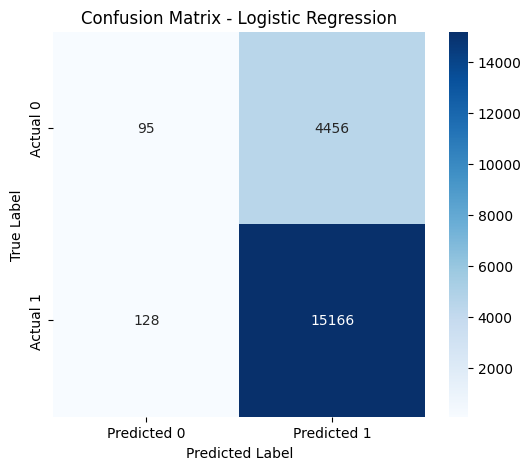


AUC - ROC Score: 0.6113


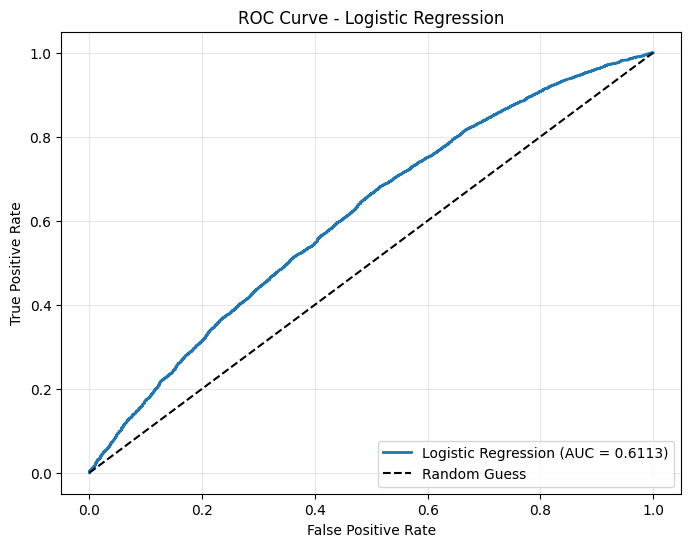

In [ ]:
# ============================
# VI.1.2. LOGISTIC REGRESSION (Đã bổ sung Time & AUC-ROC)
# ============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("Đang huấn luyện mô hình Logistic Regression...")

# ====================== Đo thời gian huấn luyện ======================
start_time = time.time()

lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42,
    solver='lbfgs'
)

lr.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"Thời gian huấn luyện: {train_time:.2f} giây")

# Dự đoán trên tập Test
start_pred = time.time()
y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]   # Xác suất lớp 1
pred_time = time.time() - start_pred

print(f"Thời gian dự đoán: {pred_time:.2f} giây")
print(f"Tổng thời gian: {train_time + pred_time:.2f} giây\n")

# ====================== Đánh giá mô hình ======================
print("\n" + "="*70)
print("CLASSIFICATION REPORT - LOGISTIC REGRESSION")
print("="*70)
print(classification_report(y_test, y_pred, digits=4,
                          target_names=['Class 0 (≤3)', 'Class 1 (≥4)']))

# Confusion Matrix
print("\nCONFUSION MATRIX:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ====================== AUC - ROC ======================
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC - ROC Score: {auc_score:.4f}")

# Vẽ đường cong ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

Đang huấn luyện mô hình Random Forest...

CLASSIFICATION REPORT - RANDOM FOREST
              precision    recall  f1-score   support

Class 0 (≤3)     0.7636    0.0277    0.0534      4551
Class 1 (≥4)     0.7752    0.9974    0.8724     15294

    accuracy                         0.7751     19845
   macro avg     0.7694    0.5126    0.4629     19845
weighted avg     0.7725    0.7751    0.6846     19845


CONFUSION MATRIX - Random Forest:
[[  126  4425]
 [   39 15255]]


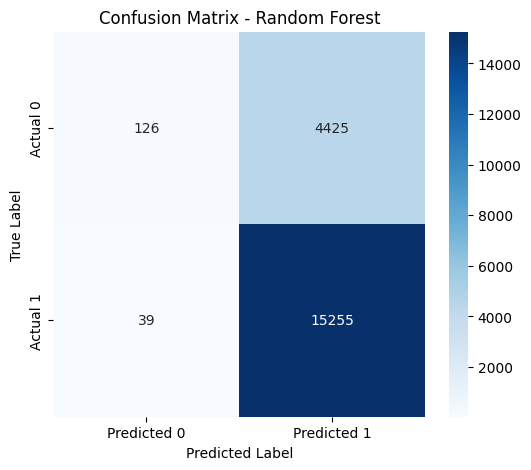


AUC-ROC Score: 0.6154


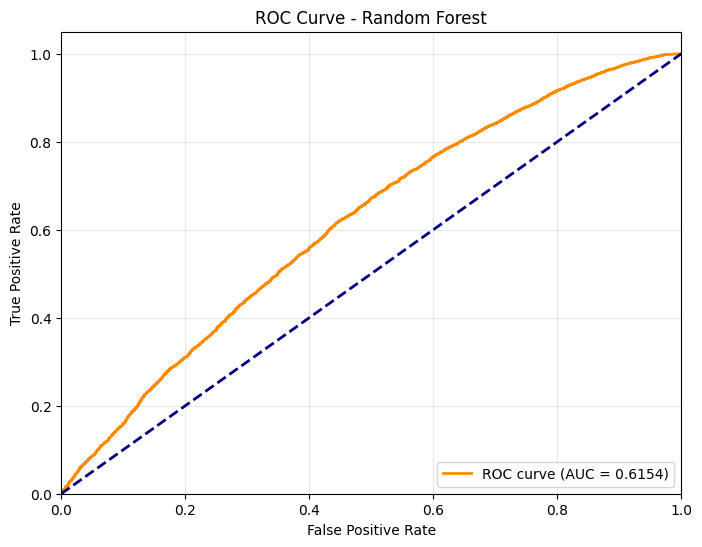


Time (s): 11.63 seconds

Top 10 Feature Importance (Random Forest):
                                            Feature  Importance
1                                     freight_value    0.285069
0                                             price    0.251218
2                                        item_count    0.123871
98            product_category_name_english_unknown    0.078071
20                                customer_state_RJ    0.024546
100                        payment_type_credit_card    0.021330
27                                customer_state_SP    0.017074
85   product_category_name_english_office_furniture    0.010698
104                            payment_type_voucher    0.009382
35     product_category_name_english_bed_bath_table    0.008073


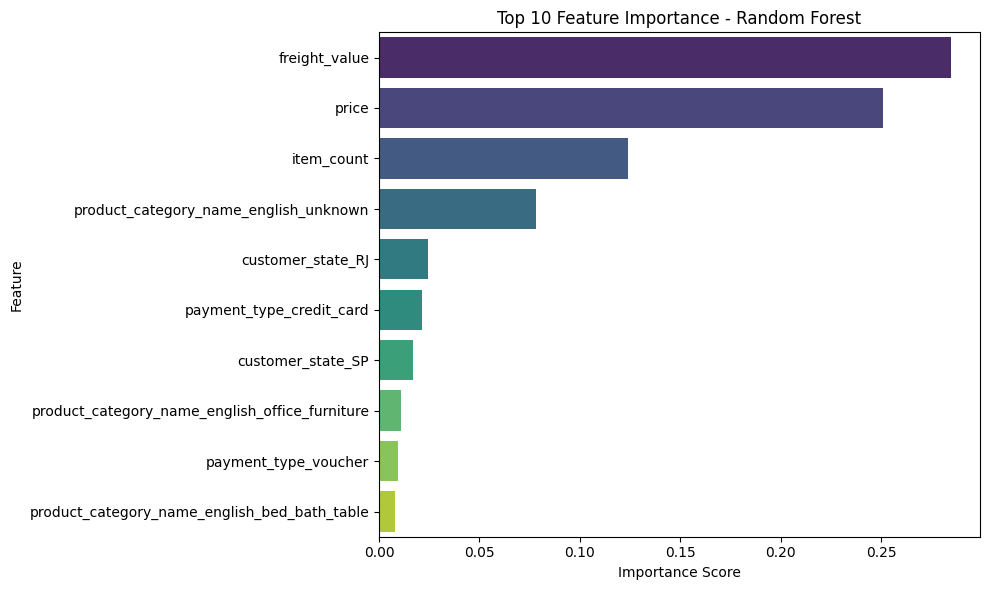

In [ ]:
# VI.1.3. RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             roc_auc_score,
                             roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

print("Đang huấn luyện mô hình Random Forest...")

# ==================== ĐO THỜI GIAN ====================
start_time = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Thời gian huấn luyện + dự đoán
train_pred_time = time.time() - start_time

# Dự đoán trên tập Test
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]   # Xác suất lớp dương (class 1)

# ==================== ĐÁNH GIÁ MÔ HÌNH ====================
print("\n" + "="*75)
print("CLASSIFICATION REPORT - RANDOM FOREST")
print("="*75)
print(classification_report(y_test, y_pred_rf,
                          digits=4,
                          target_names=['Class 0 (≤3)', 'Class 1 (≥4)']))

# Confusion Matrix
print("\nCONFUSION MATRIX - Random Forest:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

# Vẽ Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ==================== AUC-ROC ====================
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"\nAUC-ROC Score: {auc_rf:.4f}")

# Vẽ đường cong ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# ==================== THỜI GIAN ====================
print(f"\nTime (s): {train_pred_time:.2f} seconds")

# ==================== FEATURE IMPORTANCE ====================
print("\nTop 10 Feature Importance (Random Forest):")
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

# Vẽ biểu đồ Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Đang huấn luyện 3 mô hình: GaussianNB, SVC, Gradient Boosting...

1. GaussianNB
Classification Report - GaussianNB
              precision    recall  f1-score   support

Class 0 (≤3)     0.3147    0.2837    0.2984      4551
Class 1 (≥4)     0.7929    0.8162    0.8044     15294

    accuracy                         0.6941     19845
   macro avg     0.5538    0.5499    0.5514     19845
weighted avg     0.6833    0.6941    0.6884     19845

AUC-ROC Score     : 0.5842
Time (s)          : 0.31 giây

2. SVC (RBF kernel)
Classification Report - SVC
              precision    recall  f1-score   support

Class 0 (≤3)     0.2239    0.6825    0.3372      4551
Class 1 (≥4)     0.7581    0.2961    0.4259     15294

    accuracy                         0.3847     19845
   macro avg     0.4910    0.4893    0.3816     19845
weighted avg     0.6356    0.3847    0.4056     19845

AUC-ROC Score     : 0.5115
Time (s)          : 104.37 giây

3. Gradient Boosting
Classification Report - Gradient Boosting
  

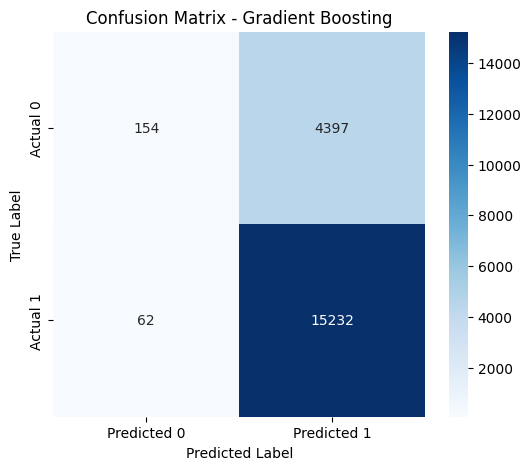


Top 10 Feature Importance - Gradient Boosting:
                                           Feature  Importance
1                                    freight_value    0.300080
2                                       item_count    0.198302
98           product_category_name_english_unknown    0.140219
0                                            price    0.104601
20                               customer_state_RJ    0.045837
85  product_category_name_english_office_furniture    0.018211
27                               customer_state_SP    0.016610
6                                customer_state_BA    0.016085
35    product_category_name_english_bed_bath_table    0.013606
96         product_category_name_english_telephony    0.009206


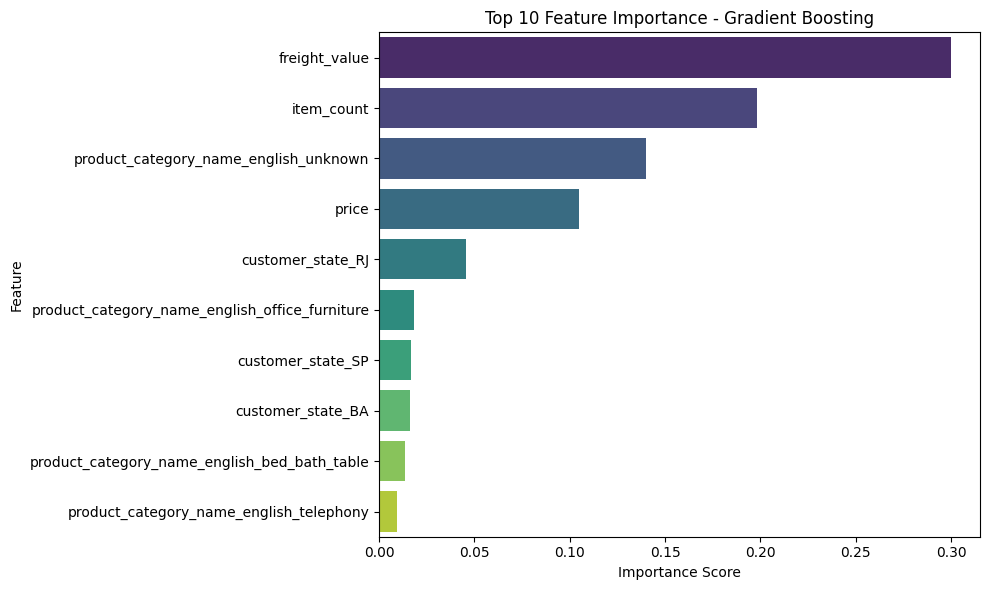

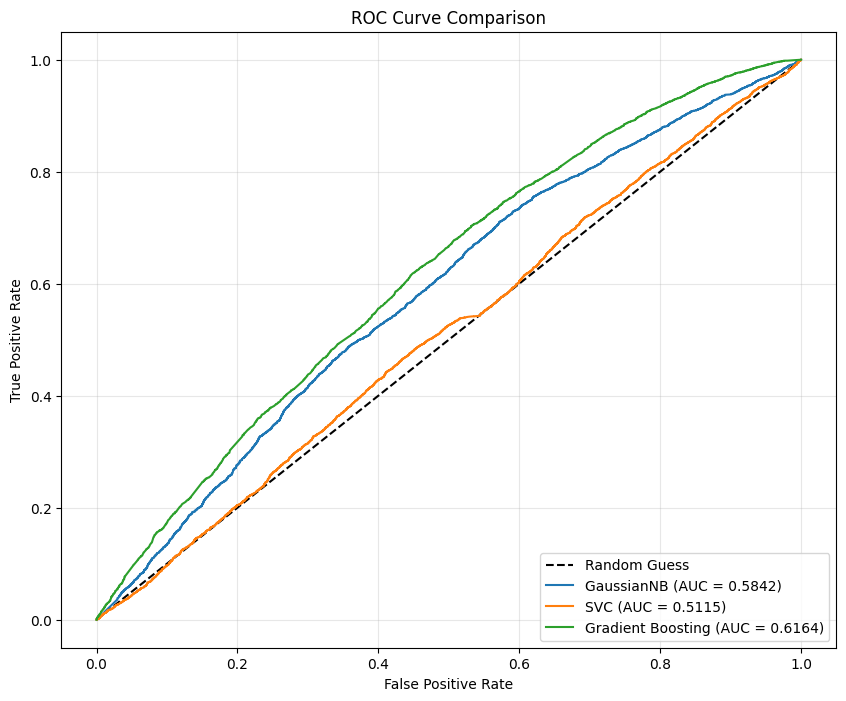

In [ ]:
# ============================
# VI.1.4. GAUSSIANNB, SVC, GRADIENT BOOSTING (Phiên bản tối ưu tốc độ)
# ============================

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

print("Đang huấn luyện 3 mô hình: GaussianNB, SVC, Gradient Boosting...\n")

# ====================== 1. Gaussian Naive Bayes ======================
print("1. GaussianNB")
start = time.time()

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
y_pred_proba_gnb = gnb.predict_proba(X_test)[:, 1]   # Dùng để tính AUC-ROC

time_gnb = time.time() - start

print("Classification Report - GaussianNB")
print(classification_report(y_test, y_pred_gnb, digits=4,
                          target_names=['Class 0 (≤3)', 'Class 1 (≥4)']))

auc_gnb = roc_auc_score(y_test, y_pred_proba_gnb)
print(f"AUC-ROC Score     : {auc_gnb:.4f}")
print(f"Time (s)          : {time_gnb:.2f} giây\n")

# ====================== 2. Support Vector Classifier (SVC) ======================
print("2. SVC (RBF kernel)")
start = time.time()

svc = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,         # BẬT probability để tính được AUC-ROC
    random_state=42,
    max_iter=500,
    tol=1e-3
)

svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
y_pred_proba_svc = svc.predict_proba(X_test)[:, 1]

time_svc = time.time() - start

print("Classification Report - SVC")
print(classification_report(y_test, y_pred_svc, digits=4,
                          target_names=['Class 0 (≤3)', 'Class 1 (≥4)']))

auc_svc = roc_auc_score(y_test, y_pred_proba_svc)
print(f"AUC-ROC Score     : {auc_svc:.4f}")
print(f"Time (s)          : {time_svc:.2f} giây\n")

# ====================== 3. Gradient Boosting ======================
print("3. Gradient Boosting")
start = time.time()

gbt = GradientBoostingClassifier(
    n_estimators=80,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    subsample=0.8
)

gbt.fit(X_train, y_train)
y_pred_gbt = gbt.predict(X_test)
y_pred_proba_gbt = gbt.predict_proba(X_test)[:, 1]

time_gbt = time.time() - start

print("Classification Report - Gradient Boosting")
print(classification_report(y_test, y_pred_gbt, digits=4,
                          target_names=['Class 0 (≤3)', 'Class 1 (≥4)']))

auc_gbt = roc_auc_score(y_test, y_pred_proba_gbt)
print(f"AUC-ROC Score     : {auc_gbt:.4f}")
print(f"Time (s)          : {time_gbt:.2f} giây\n")

# ====================== Confusion Matrix & Feature Importance (Gradient Boosting) ======================
print("\n" + "="*60)
print("CONFUSION MATRIX - Gradient Boosting")
print("="*60)
cm_gbt = confusion_matrix(y_test, y_pred_gbt)
print(cm_gbt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gbt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature Importance
print("\nTop 10 Feature Importance - Gradient Boosting:")
feature_names = X_train.columns.tolist()
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gbt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importances.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='viridis')
plt.title('Top 10 Feature Importance - Gradient Boosting')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ====================== ROC Curve cho cả 3 mô hình ======================
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# GaussianNB
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_gnb)
plt.plot(fpr, tpr, label=f'GaussianNB (AUC = {auc_gnb:.4f})')

# SVC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_svc)
plt.plot(fpr, tpr, label=f'SVC (AUC = {auc_svc:.4f})')

# Gradient Boosting
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_gbt)
plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC = {auc_gbt:.4f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

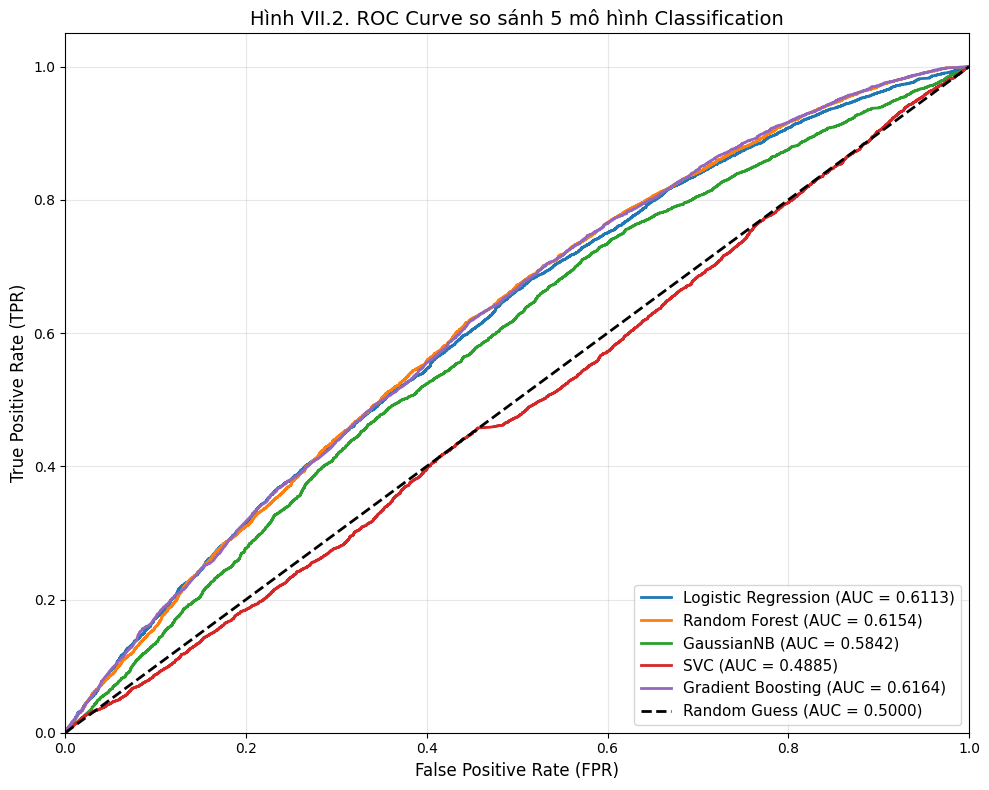


BẢNG SO SÁNH AUC-ROC CỦA 5 MÔ HÌNH
Logistic Regression   : 0.6113
Random Forest         : 0.6154
GaussianNB            : 0.5842
SVC                   : 0.4885
Gradient Boosting     : 0.6164


In [ ]:
# ============================
# VII.2. VẼ ROC CURVE SO SÁNH 5 MÔ HÌNH
# ============================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# 1. Logistic Regression
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})', linewidth=2)

# 2. Random Forest
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', linewidth=2)

# 3. Gaussian Naive Bayes
y_pred_proba_nb = gnb.predict_proba(X_test)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_proba_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, label=f'GaussianNB (AUC = {roc_auc_nb:.4f})', linewidth=2)

# 4. SVC (Support Vector Classifier)
# SVC mặc định không có predict_proba, cần dùng decision_function
y_pred_decision_svc = svc.decision_function(X_test)
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_pred_decision_svc)
roc_auc_svc = auc(fpr_svc, tpr_svc)
plt.plot(fpr_svc, tpr_svc, label=f'SVC (AUC = {roc_auc_svc:.4f})', linewidth=2)

# 5. Gradient Boosting
y_pred_proba_gb = gbt.predict_proba(X_test)[:, 1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_gb:.4f})', linewidth=2)

# Đường chéo ngẫu nhiên (Random Guess)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)', linewidth=2)

# Cấu hình biểu đồ
plt.title('Hình VII.2. ROC Curve so sánh 5 mô hình Classification', fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

# In ra bảng AUC để dễ so sánh
print("\n" + "="*60)
print("BẢNG SO SÁNH AUC-ROC CỦA 5 MÔ HÌNH")
print("="*60)
print(f"Logistic Regression   : {roc_auc_lr:.4f}")
print(f"Random Forest         : {roc_auc_rf:.4f}")
print(f"GaussianNB            : {roc_auc_nb:.4f}")
print(f"SVC                   : {roc_auc_svc:.4f}")
print(f"Gradient Boosting     : {roc_auc_gb:.4f}")
print("="*60)


In [ ]:
import joblib

In [ ]:
from google.colab import files
import joblib

# ==================== LƯU VÀ TẢI MODEL ====================
# Lấy mô hình Gradient Boosting đã huấn luyện
trained_model = gbt   # hoặc models['Gradient Boosting'].best_estimator_ nếu bạn dùng GridSearch

# Đặt tên file model
model_filename = 'gradient_boosting_model.joblib'

# Lưu model
joblib.dump(trained_model, model_filename)
print(f"✅ Mô hình đã được lưu thành công tại: {model_filename}")

# Tải model về máy
files.download(model_filename)


# ==================== TẢI THÊM FILE .CSV (nếu có) ====================
# Thay tên file csv thực tế của bạn vào đây
csv_filename = 'your_data.csv'        # ←←← THAY TÊN FILE CSV CỦA BẠN

# Kiểm tra file csv có tồn tại không rồi mới tải
import os
if os.path.exists(csv_filename):
    print(f"✅ Đang tải file CSV: {csv_filename}")
    files.download(csv_filename)
else:
    print(f"⚠️ Không tìm thấy file: {csv_filename}")

✅ Mô hình đã được lưu thành công tại: gradient_boosting_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⚠️ Không tìm thấy file: your_data.csv


In [ ]:
# ============================
# VI.1.5. HYPERPARAMETER TUNING
# ============================
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
import time
import warnings
import pandas as pd

warnings.filterwarnings('ignore')

print("=== VI.1.5. HYPERPARAMETER TUNING ===\n")

models = {}
results_summary = []

# ====================== 1. Logistic Regression ======================
print("1. Tuning Logistic Regression...")
start = time.time()

param_grid_lr = {
    'classifier__C': [0.1, 1.0, 10],
    'classifier__max_iter': [1000]
}

lr_pipeline = Pipeline([('classifier', LogisticRegression(random_state=42, solver='lbfgs'))])

grid_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=5, scoring='f1_macro',
                       n_jobs=-1, verbose=1)

grid_lr.fit(X_train, y_train)
models['Logistic Regression'] = grid_lr

print(f"Best params: {grid_lr.best_params_}")
print(f"Best CV f1_macro: {grid_lr.best_score_:.4f}")
print(f"Thời gian: {time.time() - start:.2f} giây\n")

results_summary.append(['Logistic Regression', grid_lr.best_params_, round(grid_lr.best_score_, 4)])

# ====================== 2. Random Forest ======================
print("2. Tuning Random Forest...")
start = time.time()

param_dist_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 15, 20],
    'classifier__min_samples_split': [2, 5]
}

rf_pipeline = Pipeline([('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))])

grid_rf = RandomizedSearchCV(rf_pipeline, param_dist_rf, n_iter=8, cv=5,
                             scoring='f1_macro', n_jobs=-1, verbose=1, random_state=42)

grid_rf.fit(X_train, y_train)
models['Random Forest'] = grid_rf

print(f"Best params: {grid_rf.best_params_}")
print(f"Best CV f1_macro: {grid_rf.best_score_:.4f}")
print(f"Thời gian: {time.time() - start:.2f} giây\n")

results_summary.append(['Random Forest', grid_rf.best_params_, round(grid_rf.best_score_, 4)])

# ====================== 3. GaussianNB ======================
print("3. Tuning GaussianNB...")
start = time.time()

param_grid_nb = {'classifier__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]}

nb_pipeline = Pipeline([('classifier', GaussianNB())])

grid_nb = GridSearchCV(nb_pipeline, param_grid_nb, cv=5, scoring='f1_macro',
                       n_jobs=-1, verbose=1)

grid_nb.fit(X_train, y_train)
models['GaussianNB'] = grid_nb

print(f"Best params: {grid_nb.best_params_}")
print(f"Best CV f1_macro: {grid_nb.best_score_:.4f}")
print(f"Thời gian: {time.time() - start:.2f} giây\n")

results_summary.append(['GaussianNB', grid_nb.best_params_, round(grid_nb.best_score_, 4)])

# ====================== 4. Gradient Boosting ======================
print("4. Tuning Gradient Boosting...")
start = time.time()

param_dist_gbt = {
    'classifier__n_estimators': [100, 150],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1]
}

gbt_pipeline = Pipeline([('classifier', GradientBoostingClassifier(random_state=42))])

grid_gbt = RandomizedSearchCV(gbt_pipeline, param_dist_gbt, n_iter=8, cv=5,
                              scoring='f1_macro', n_jobs=-1, verbose=1, random_state=42)

grid_gbt.fit(X_train, y_train)
models['Gradient Boosting'] = grid_gbt

print(f"Best params: {grid_gbt.best_params_}")
print(f"Best CV f1_macro: {grid_gbt.best_score_:.4f}")
print(f"Thời gian: {time.time() - start:.2f} giây\n")

results_summary.append(['Gradient Boosting', grid_gbt.best_params_, round(grid_gbt.best_score_, 4)])

print("=== HOÀN TẤT HYPERPARAMETER TUNING ===\n")

# ====================== TÓM TẮT KẾT QUẢ ======================
print("=== TÓM TẮT KẾT QUẢ GRIDSEARCHCV ===")
summary_df = pd.DataFrame(results_summary, columns=['Model', 'Best Params', 'Best CV f1_macro'])
print(summary_df.to_string(index=False))

print("\n=== CHI TIẾT CV RESULTS (DÙNG ĐỂ CHỤP HÌNH VI.6) ===")
for name, model in models.items():
    print(f"\n--- {name} ---")
    print(f"Best params : {model.best_params_}")
    print(f"Best score  : {model.best_score_:.4f}")
    # In một phần cv_results_ để chụp ảnh
    cv_results = pd.DataFrame(model.cv_results_)
    cols_to_show = [col for col in cv_results.columns if col.startswith('param_') or col in ['mean_test_score', 'rank_test_score']]
    print(cv_results[cols_to_show].sort_values('rank_test_score').head(6))  # hiển thị top 6 tốt nhất

=== VI.1.5. HYPERPARAMETER TUNING ===

1. Tuning Logistic Regression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best params: {'classifier__C': 10, 'classifier__max_iter': 1000}
Best CV f1_macro: 0.4600
Thời gian: 278.60 giây

2. Tuning Random Forest...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__max_depth': 20}
Best CV f1_macro: 0.4756
Thời gian: 430.08 giây

3. Tuning GaussianNB...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'classifier__var_smoothing': 1e-08}
Best CV f1_macro: 0.5561
Thời gian: 3.96 giây

4. Tuning Gradient Boosting...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'classifier__n_estimators': 150, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1}
Best CV f1_macro: 0.4801
Thời gian: 848.54 giây

=== HOÀN TẤT HYPERPARAMETER TUNING ===

=== TÓM TẮT KẾT QUẢ GRIDSEARCHCV ===

In [ ]:
import pandas as pd
import numpy as np

print("🔄 Đang chuẩn bị file data.csv theo yêu cầu...")

# ==================== TẠO DỮ LIỆU SẠCH TỪ DF ĐÃ MERGE ====================
# Sử dụng dataframe df đã merge ở phần trước của bạn

df_clean = df.copy()

# 1. Chọn các cột cần thiết (Features + Target)
columns_to_keep = [
    'price',
    'freight_value',
    'item_count',
    'customer_state',
    'product_category_name_english',
    'payment_type',
    'review_score'          # Giữ nguyên review_score để sau chuyển thành binary
]

df_clean = df_clean[columns_to_keep]

# 2. Tạo cột Target nhị phân (theo yêu cầu trong hình)
df_clean['review_score_binary'] = np.where(df_clean['review_score'] >= 4, 1, 0)

# 3. Xóa cột review_score gốc (chỉ giữ binary)
df_clean = df_clean.drop(columns=['review_score'])

# 4. Xử lý missing values (rất quan trọng để AI không lỗi)
df_clean = df_clean.fillna({
    'price': df_clean['price'].median(),
    'freight_value': df_clean['freight_value'].median(),
    'item_count': 1,
    'customer_state': 'unknown',
    'product_category_name_english': 'unknown',
    'payment_type': 'unknown'
})

# 5. Đảm bảo các cột số là kiểu số (int/float)
df_clean['price'] = df_clean['price'].astype(float)
df_clean['freight_value'] = df_clean['freight_value'].astype(float)
df_clean['item_count'] = df_clean['item_count'].astype(int)
df_clean['review_score_binary'] = df_clean['review_score_binary'].astype(int)

# 6. Đổi tên cột cho dễ hiểu và phù hợp với Streamlit (tùy chọn nhưng nên làm)
df_clean = df_clean.rename(columns={
    'product_category_name_english': 'product_category',
    'review_score_binary': 'target'   # hoặc giữ là review_score_binary cũng được
})

print(f"✅ File data.csv đã sẵn sàng!")
print(f"   Shape: {df_clean.shape}")
print(f"   Các cột: {df_clean.columns.tolist()}")
print("\nPhân bố Target:")
print(df_clean['target'].value_counts(normalize=True))

# ==================== LƯU VÀ TẢI FILE CSV ====================
csv_filename = 'data.csv'

# Lưu file CSV
df_clean.to_csv(csv_filename, index=False, encoding='utf-8')

print(f"\n✅ Đã lưu file: {csv_filename}")

# Tải file về máy (Google Colab)
from google.colab import files
files.download(csv_filename)

🔄 Đang chuẩn bị file data.csv theo yêu cầu...
✅ File data.csv đã sẵn sàng!
   Shape: (99224, 7)
   Các cột: ['price', 'freight_value', 'item_count', 'customer_state', 'product_category', 'payment_type', 'target']

Phân bố Target:
target
1    0.77068
0    0.22932
Name: proportion, dtype: float64

✅ Đã lưu file: data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime
import kagglehub
import os # Import os module to check for file existence
import warnings
warnings.filterwarnings('ignore') # Suppress warnings during data loading/processing

print("🔄 Đang thêm cột delivery_days vào data.csv...")

# ====================== 1. Đảm bảo DataFrame 'df' tồn tại ======================
# Nếu df chưa được định nghĩa (ví dụ: kernel restart), sẽ tải lại và merge dữ liệu gốc
try:
    _ = df.head() # Kiểm tra xem df có tồn tại không
except NameError:
    print("⚠️ DataFrame 'df' chưa được định nghĩa. Đang tải và merge dữ liệu gốc để tạo 'df'...")
    # Tải các dataframe gốc (tương tự cell gVnTJNeQA7OX)
    path_dir = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
    base_path = path_dir

    orders_raw = pd.read_csv(f"{base_path}/olist_orders_dataset.csv")
    order_items_raw = pd.read_csv(f"{base_path}/olist_order_items_dataset.csv")
    order_reviews_raw = pd.read_csv(f"{base_path}/olist_order_reviews_dataset.csv")
    customers_raw = pd.read_csv(f"{base_path}/olist_customers_dataset.csv")
    products_raw = pd.read_csv(f"{base_path}/olist_products_dataset.csv")
    order_payments_raw = pd.read_csv(f"{base_path}/olist_order_payments_dataset.csv")
    category_translation_raw = pd.read_csv(f"{base_path}/product_category_name_translation.csv")

    # Merge dữ liệu để tạo 'df' (tương tự cell lkiy8UcBCqBy)
    df = order_reviews_raw[['order_id', 'review_score']].copy()
    df = df.merge(orders_raw[['order_id', 'customer_id', 'order_purchase_timestamp',
                          'order_status']], on='order_id', how='left')
    df = df.merge(customers_raw[['customer_id', 'customer_unique_id', 'customer_city',
                             'customer_state']], on='customer_id', how='left')
    items = order_items_raw.groupby('order_id').agg({
        'product_id': 'first',
        'price': 'sum',
        'freight_value': 'sum',
        'order_item_id': 'count'
    }).reset_index().rename(columns={'order_item_id': 'item_count'})
    df = df.merge(items, on='order_id', how='left')
    df = df.merge(products_raw[['product_id', 'product_category_name']], on='product_id', how='left')
    df = df.merge(category_translation_raw, on='product_category_name', how='left')
    payments = order_payments_raw.groupby('order_id')['payment_type'].agg(lambda x: x.mode()[0] if not x.empty else np.nan).reset_index()
    df = df.merge(payments, on='order_id', how='left')
    print("✅ DataFrame 'df' đã được tạo lại từ dữ liệu gốc thành công.")
else:
    print("✅ DataFrame 'df' đã có sẵn.")

# ====================== 2. Chuẩn bị DataFrame 'df_clean' với 'order_id' ======================
# Tạo df_clean từ df, đảm bảo giữ lại 'order_id' cho việc merge
df_clean = df.copy()

columns_to_keep_for_df_clean = [
    'order_id', # GIỮ LẠI order_id ĐỂ MERGE delivery_days
    'price',
    'freight_value',
    'item_count',
    'customer_state',
    'product_category_name_english',
    'payment_type',
    'review_score'
]
df_clean = df_clean[columns_to_keep_for_df_clean]

df_clean['review_score_binary'] = np.where(df_clean['review_score'] >= 4, 1, 0)
df_clean = df_clean.drop(columns=['review_score'])

df_clean = df_clean.fillna({
    'price': df_clean['price'].median(),
    'freight_value': df_clean['freight_value'].median(),
    'item_count': 1,
    'customer_state': 'unknown',
    'product_category_name_english': 'unknown',
    'payment_type': 'unknown'
})

df_clean['price'] = df_clean['price'].astype(float)
df_clean['freight_value'] = df_clean['freight_value'].astype(float)
df_clean['item_count'] = df_clean['item_count'].astype(int)
df_clean['review_score_binary'] = df_clean['review_score_binary'].astype(int)

df_clean = df_clean.rename(columns={
    'product_category_name_english': 'product_category',
    'review_score_binary': 'target'
})
print("✅ DataFrame 'df_clean' đã được chuẩn bị.")

# ====================== 3. Tính và Merge 'delivery_days' ======================
print("Đang tính toán 'delivery_days'...")
# Tải lại 'orders' dataframe để tính thời gian giao hàng,
# đảm bảo nó luôn có sẵn và là bản gốc
# Use orders_raw if already loaded, otherwise load it.
try:
    _ = orders_raw.head() # Check if orders_raw exists from previous block
except NameError:
    # If not, it means df existed and we didn't enter the NameError block
    # So we need to load orders_raw explicitly here.
    path_dir = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
    base_path = path_dir
    orders_raw = pd.read_csv(f"{base_path}/olist_orders_dataset.csv")

temp_delivery = orders_raw[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date']].copy()
temp_delivery['order_purchase_timestamp'] = pd.to_datetime(temp_delivery['order_purchase_timestamp'])
temp_delivery['order_delivered_customer_date'] = pd.to_datetime(temp_delivery['order_delivered_customer_date'])
temp_delivery['delivery_days'] = (temp_delivery['order_delivered_customer_date'] - temp_delivery['order_purchase_timestamp']).dt.days
temp_delivery['delivery_days'] = temp_delivery['delivery_days'].round().astype('Int64')
temp_delivery['delivery_days'] = temp_delivery['delivery_days'].clip(lower=0)

df_clean = df_clean.merge(
    temp_delivery[['order_id', 'delivery_days']],
    on='order_id',
    how='left'
)

df_clean['delivery_days'] = df_clean['delivery_days'].fillna(df_clean['delivery_days'].median())
df_clean['delivery_days'] = df_clean['delivery_days'].astype(int)
print("✅ Cột 'delivery_days' đã được thêm vào.")

# ====================== 4. Xóa 'order_id' và kiểm tra kết quả ======================
# Sau khi merge, order_id không còn là feature
df_clean = df_clean.drop(columns=['order_id'], errors='ignore')

print(f"✅ Đã thêm cột delivery_days thành công!")
print(f"Shape mới: {df_clean.shape}")
print(f"\nThống kê delivery_days:")
print(df_clean['delivery_days'].describe())

# Xem 10 dòng đầu
print("\n10 dòng mẫu:")
print(df_clean[['price', 'freight_value', 'delivery_days', 'target']].head(10))

# ====================== 5. LƯU FILE MỚI ======================
csv_filename = 'data.csv'
df_clean.to_csv(csv_filename, index=False, encoding='utf-8')
print(f"\n💾 Đã ghi đè file {csv_filename} với cột delivery_days mới!")

# Tải file về máy
from google.colab import files
files.download(csv_filename)

🔄 Đang thêm cột delivery_days vào data.csv...
⚠️ DataFrame 'df' chưa được định nghĩa. Đang tải và merge dữ liệu gốc để tạo 'df'...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
✅ DataFrame 'df' đã được tạo lại từ dữ liệu gốc thành công.
✅ DataFrame 'df_clean' đã được chuẩn bị.
Đang tính toán 'delivery_days'...
✅ Cột 'delivery_days' đã được thêm vào.
✅ Đã thêm cột delivery_days thành công!
Shape mới: (99224, 8)

Thống kê delivery_days:
count    99224.000000
mean        11.999506
std          9.331826
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        208.000000
Name: delivery_days, dtype: float64

10 dòng mẫu:
     price  freight_value  delivery_days  target
0   370.00          27.26              6       1
1    79.79           8.30              9       1
2   149.00          45.12             13       1
3   179.99          42.85             10       1
4  1199.00         134.25             18       1
5   418.70   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>